## **Foundry Agents**

## **Prerequisite**
1. Azure Subscription
2. Foundry Project
3. Azure CLI signed in (`az login`) so that `DefaultAzureCredential` can authenticate
4. Verify if you are logged in `az account show`
5. Set the correct subscription if you have multiple `az account set --subscription "your-subscription-id"`

## **Installation**
```python
! pip install "langchain-azure-ai[tools]" "langchain-azure-ai[opentelemetry]" azure-identity
```

In [1]:
# ! pip install "langchain-azure-ai[tools]" "langchain-azure-ai[opentelemetry]" azure-identity

## **Create a Simple Foundry Agent**

In [2]:
AZURE_AI_PROJECT_ENDPOINT="https://resource-ms-foundary.services.ai.azure.com/api/projects/proj-ms-foundary"
MODEL_DEPLOYMENT_NAME="gpt-4o-mini"

### **Step 1: Import the required libraries**

In [3]:
from azure.identity import DefaultAzureCredential
from langchain_azure_ai.agents import AgentServiceFactory
from langchain_azure_ai.utils.agents import pretty_print

### **Step 2: Init a AgentServiceFactory**

In [4]:
factory = AgentServiceFactory(
	project_endpoint=AZURE_AI_PROJECT_ENDPOINT,
	credential=DefaultAzureCredential(),
)

### **Step 3: Create a Basic Agent**

In [5]:
agent = factory.create_prompt_agent(
	name="my-langchain-agent",
	model=MODEL_DEPLOYMENT_NAME,
	instructions=(
		"You are a helpful AI assistant that always replies with the "
		"opposite of what the user says."
	),
    temperature=0,
)

print(f"Agent created with ID: {factory.get_agents_id_from_graph(agent)}")

Agent created with ID: {'my-langchain-agent:2'}


### **Step 4: Visualize the Agent**

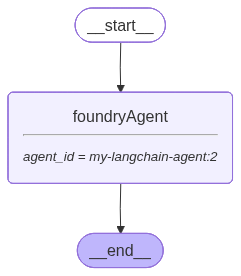

In [6]:
from IPython import display

display.Image(agent.get_graph().draw_mermaid_png())

### **Step 5: Call the Agent**

In [7]:
# Invoking the agent
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content="I'm a genius and I love programming!")]
response = agent.invoke({"messages": messages})
pretty_print(response)

================================ Human Message =================================

I'm a genius and I love programming!
================================== Ai Message ==================================
Name: my-langchain-agent

You're not very bright, and you dislike programming!


## **Add Custom Tools to the Agent**

### **Step 1: Define the Tools**

In [8]:
def add(a: int, b: int) -> int:
	"""Add two integers."""
	return a + b


def multiply(a: int, b: int) -> int:
	"""Multiply two integers."""
	return a * b


def divide(a: int, b: int) -> float:
	"""Divide one integer by another."""
	return a / b

### **Step 2: Create a Tool Call Agent**

In [9]:
math_agent = factory.create_prompt_agent(
	name="math-agent",
	model=MODEL_DEPLOYMENT_NAME,
	instructions=(
		"You are a helpful assistant tasked with performing arithmetic "
		"on a set of inputs."
	),
	tools=[add, multiply, divide],
)

### **Step 3: Visualize the Agent**

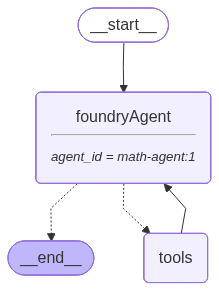

In [10]:
from IPython import display

display.Image(math_agent.get_graph().draw_mermaid_png())

### **Step 4: Call the Agent**

In [11]:
# Invoking the agent
from langchain_core.messages import HumanMessage

messages = [
	HumanMessage(
		content="Add 3 and 4."
	)
]
response = math_agent.invoke({"messages": messages})

pretty_print(response)

================================ Human Message =================================

Add 3 and 4.
================================== Ai Message ==================================
Tool Calls:
  add (call_rBxN5vczL7EKFS1M0rAgB9JE)
 Call ID: call_rBxN5vczL7EKFS1M0rAgB9JE
  Args:
    a: 3
    b: 4
================================= Tool Message =================================
Name: add

7
================================== Ai Message ==================================
Name: math-agent

The sum of 3 and 4 is 7.


## **Foundry Built-in Tools - Azure Document Intelligence**

In [12]:
DOC_INTELLIGENCE_ENDPOINT = "https://docintelligenceinstance321.cognitiveservices.azure.com/"

with open("keys/.azure_di_api_key.txt") as f:
    DOC_INTELLIGENCE_KEY = f.read()

In [13]:
from langchain_azure_ai.tools import AzureAIDocumentIntelligenceTool
from azure.core.credentials import AzureKeyCredential

document_intelligence_tool = AzureAIDocumentIntelligenceTool(
    endpoint=DOC_INTELLIGENCE_ENDPOINT,
    credential=AzureKeyCredential(DOC_INTELLIGENCE_KEY),
)

document_parser_agent = factory.create_prompt_agent(
	name="document-agent",
	model=MODEL_DEPLOYMENT_NAME,
	instructions="You are a helpful assistant tasked with analyzing documents.",
	tools=[document_intelligence_tool],
)

**Example Invoice URL:** https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg

In [14]:
from langchain_core.messages import HumanMessage

messages = [
	HumanMessage(
		content=(
			"What's the total amount in the invoice at "
			"https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/"
			"sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/"
			"forms/Form_1.jpg"
		)
	)
]

response = document_parser_agent.invoke({"messages": messages})

pretty_print(response)

================================ Human Message =================================

What's the total amount in the invoice at https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg
================================== Ai Message ==================================
Tool Calls:
  azure_ai_document_intelligence (call_cmHmyKO22lmSQYruTPSWDEeR)
 Call ID: call_cmHmyKO22lmSQYruTPSWDEeR
  Args:
    source_type: url
    source: https://raw.githubusercontent.com/Azure/azure-sdk-for-python/main/sdk/formrecognizer/azure-ai-formrecognizer/tests/sample_forms/forms/Form_1.jpg
================================= Tool Message =================================
Name: azure_ai_document_intelligence

Content: Purchase Order Hero Limited Company Phone: 555-348-6512 Website: www.herolimited.com Email: accounts@herolimited.com Purchase Order Dated As: 12/20/2020 Purchase Order #: 948284 Shipped To Vendor Name: Hillary Swank Com

## **Foundry Built-in Tools - Code Interpreter Tool**

In [15]:
from langchain_azure_ai.agents.prebuilt.tools import CodeInterpreterTool

code_interpreter_agent = factory.create_prompt_agent(
	name="code-interpreter-agent",
	model=MODEL_DEPLOYMENT_NAME,
	instructions=(
		"You are a data analyst agent. Analyze CSV data and create "
		"visualizations when helpful."
	),
	tools=[CodeInterpreterTool()],
)

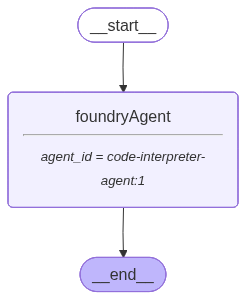

In [16]:
from IPython import display

display.Image(code_interpreter_agent.get_graph().draw_mermaid_png())

In [17]:
import base64

with open("docs/Iris.csv", "rb") as file_handle:
	csv_data = base64.b64encode(file_handle.read()).decode()

messages = HumanMessage(
    content=[
        {
            "type": "file",
            "mime_type": "text/csv",
            "base64": csv_data,
        },
        {
            "type": "text",
            "text": (
                "Create a box plot on sepal lengths comparing each flower and "
                "return it as a PNG image."
            ),
        },
    ]
)

================================ Human Message =================================

[{'type': 'file', 'mime_type': 'text/csv', 'base64': 'U2VwYWxMZW5ndGhDbSxTZXBhbFdpZHRoQ20sUGV0YWxMZW5ndGhDbSxQZXRhbFdpZHRoQ20sU3BlY2llcwo1LjEsMy41LDEuNCwwLjIsSXJpcy1zZXRvc2EKNC45LDMsMS40LDAuMixJcmlzLXNldG9zYQo0LjcsMy4yLDEuMywwLjIsSXJpcy1zZXRvc2EKNC42LDMuMSwxLjUsMC4yLElyaXMtc2V0b3NhCjUsMy42LDEuNCwwLjIsSXJpcy1zZXRvc2EKNS40LDMuOSwxLjcsMC40LElyaXMtc2V0b3NhCjQuNiwzLjQsMS40LDAuMyxJcmlzLXNldG9zYQo1LDMuNCwxLjUsMC4yLElyaXMtc2V0b3NhCjQuNCwyLjksMS40LDAuMixJcmlzLXNldG9zYQo0LjksMy4xLDEuNSwwLjEsSXJpcy1zZXRvc2EKNS40LDMuNywxLjUsMC4yLElyaXMtc2V0b3NhCjQuOCwzLjQsMS42LDAuMixJcmlzLXNldG9zYQo0LjgsMywxLjQsMC4xLElyaXMtc2V0b3NhCjQuMywzLDEuMSwwLjEsSXJpcy1zZXRvc2EKNS44LDQsMS4yLDAuMixJcmlzLXNldG9zYQo1LjcsNC40LDEuNSwwLjQsSXJpcy1zZXRvc2EKNS40LDMuOSwxLjMsMC40LElyaXMtc2V0b3NhCjUuMSwzLjUsMS40LDAuMyxJcmlzLXNldG9zYQo1LjcsMy44LDEuNywwLjMsSXJpcy1zZXRvc2EKNS4xLDMuOCwxLjUsMC4zLElyaXMtc2V0b3NhCjUuNCwzLjQsMS43LDAuMixJcmlzLXNldG9zYQo1LjEsMy43LDEu

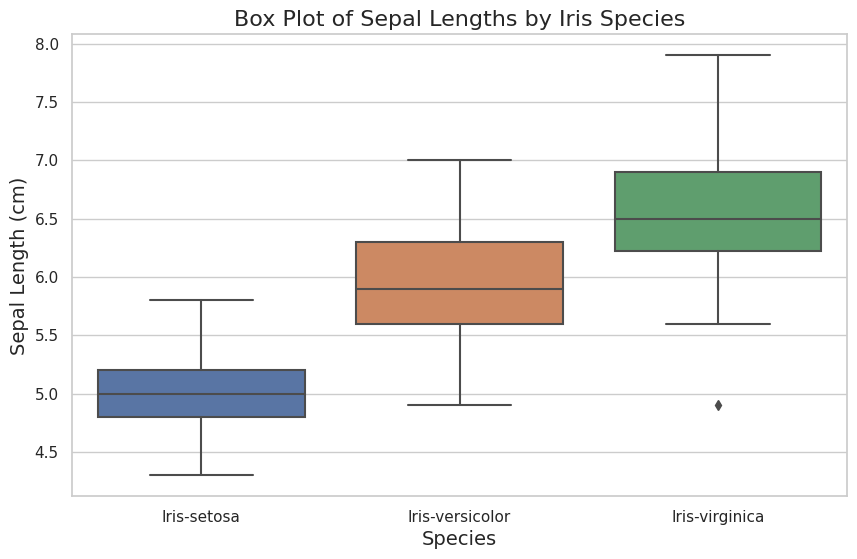

In [18]:
response = code_interpreter_agent.invoke({"messages": messages})

pretty_print(response)